Import libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


Load clean FCF data:

In [2]:
fcf = pd.read_csv("../data/fundamentals/fcf_clean.csv", index_col=0)
fcf


,FCF
2022-03-31,6.073426e+11
2023-03-31,5.208209e+11
2024-03-31,1.076160e+12
2025-03-31,1.262015e+12


Visualise FCF:

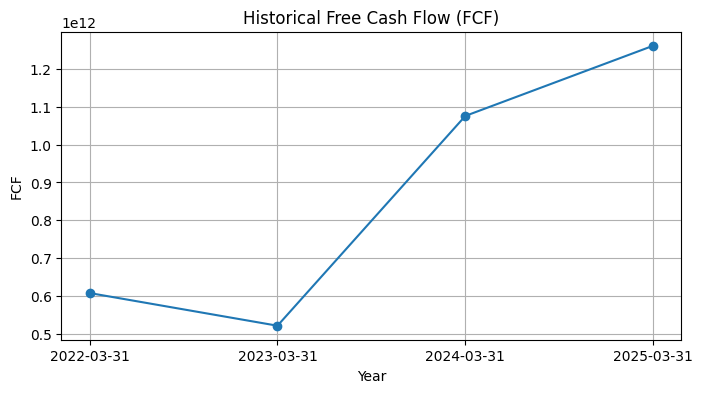

In [3]:
plt.figure(figsize=(8,4))
plt.plot(fcf.index, fcf["FCF"], marker="o")
plt.title("Historical Free Cash Flow (FCF)")
plt.xlabel("Year")
plt.ylabel("FCF")
plt.grid(True)
plt.show()


Convert FCF to NumPy array:

In [4]:
fcf_values = fcf["FCF"].values.reshape(-1, 1)
fcf_values


array([[6.0734260e+11],
       [5.2082090e+11],
       [1.0761604e+12],
       [1.2620147e+12]])

Scale the data:

In [5]:
scaler = StandardScaler()
fcf_scaled = scaler.fit_transform(fcf_values)

fcf_scaled


array([[-0.83340133],
       [-1.11154795],
       [ 0.67373603],
       [ 1.27121325]])

Create Time-Series Dataset:

In [6]:
def create_dataset(data, look_back=3):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)


In [7]:
LOOK_BACK = 3

X, y = create_dataset(fcf_scaled, LOOK_BACK)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1, 3, 1)
y shape: (1, 1)


Train–test split:

In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


PYTORCH LSTM FOR FCF FORECASTING:

Install & verify PyTorch:

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt





Load clean FCF data:

In [10]:
fcf = pd.read_csv("../data/fundamentals/fcf_clean.csv", index_col=0)
fcf_values = fcf["FCF"].values.reshape(-1, 1)


MANUAL SCALING:

In [11]:
mean = np.mean(fcf_values)
std = np.std(fcf_values)

# safety guard
std = std if std != 0 else 1

fcf_scaled = (fcf_values - mean) / std


Create time-series dataset:

In [12]:
def create_dataset(data, look_back=2):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

LOOK_BACK = 2
X, y = create_dataset(fcf_scaled, LOOK_BACK)

y = y.reshape(-1, 1)


Train-test split:

In [13]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


Convert to PyTorch tensors:

In [14]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


Define PyTorch LSTM model:

In [15]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


Initialize model, loss, optimizer:

In [16]:
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)


TRAINING LOOP:

In [17]:
epochs = 300

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    output = model(X_train_t)
    loss = criterion(output, y_train_t)

    if torch.isnan(loss):
        print(" !!! NaN loss detected — stopping")
        break

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 0.194808
Epoch 50, Loss: 0.092713
Epoch 100, Loss: 0.011479
Epoch 150, Loss: 0.000013
Epoch 200, Loss: 0.000000
Epoch 250, Loss: 0.000000


Predictions:

In [18]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_t).numpy()
    test_preds = model(X_test_t).numpy()


Inverse scaling (manual):

In [19]:
train_preds_inv = train_preds * std + mean
y_train_inv = y_train * std + mean

test_preds_inv = test_preds * std + mean
y_test_inv = y_test * std + mean


Plot Actual vs Predicted FCF:

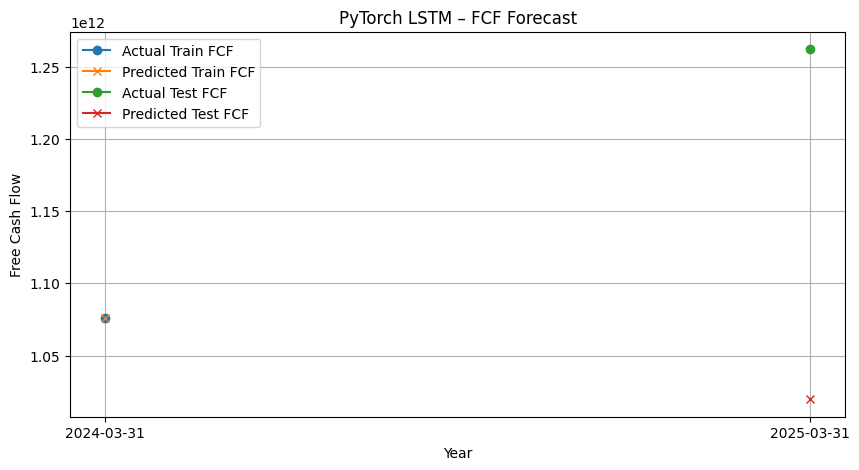

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    fcf.index[LOOK_BACK:LOOK_BACK+len(y_train_inv)],
    y_train_inv,
    label="Actual Train FCF",
    marker="o"
)

plt.plot(
    fcf.index[LOOK_BACK:LOOK_BACK+len(y_train_inv)],
    train_preds_inv,
    label="Predicted Train FCF",
    marker="x"
)

plt.plot(
    fcf.index[LOOK_BACK+len(y_train_inv):],
    y_test_inv,
    label="Actual Test FCF",
    marker="o"
)

plt.plot(
    fcf.index[LOOK_BACK+len(y_train_inv):],
    test_preds_inv,
    label="Predicted Test FCF",
    marker="x"
)

plt.title("PyTorch LSTM – FCF Forecast")
plt.xlabel("Year")
plt.ylabel("Free Cash Flow")
plt.legend()
plt.grid(True)
plt.show()


Forecast NEXT 5 YEARS (LSTM):

In [21]:
future_steps = 5
last_window = fcf_scaled[-LOOK_BACK:]

future_scaled = []

for _ in range(future_steps):
    x = torch.tensor(last_window.reshape(1, LOOK_BACK, 1), dtype=torch.float32)
    with torch.no_grad():
        pred = model(x).numpy()
    future_scaled.append(pred[0,0])
    last_window = np.append(last_window[1:], pred).reshape(LOOK_BACK,1)

future_scaled = np.array(future_scaled).reshape(-1,1)
future_fcf = future_scaled * std + mean

future_fcf


array([[9.50768869e+11],
       [9.67102857e+11],
       [9.90914539e+11],
       [9.86813964e+11],
       [9.85138114e+11]])

PROPHET TREND ANCHORING:

Import Prophet:

In [22]:
from prophet import Prophet


c:\Users\ASUS\OneDrive\Desktop\financial_digital_twin\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prepare data for Prophet:

Convert FCF data:

In [23]:
prophet_df = fcf.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_df


,ds,y
0,2022-03-31,6.073426e+11
1,2023-03-31,5.208209e+11
2,2024-03-31,1.076160e+12
3,2025-03-31,1.262015e+12


Initialize Prophet model:

In [24]:
prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2  # controls trend flexibility
)


Fit Prophet model:

In [25]:
prophet_model.fit(prophet_df)


10:26:55 - cmdstanpy - INFO - Chain [1] start processing
10:26:56 - cmdstanpy - INFO - Chain [1] done processing


Create future dataframe (next 5 years):

In [26]:
future_years = prophet_model.make_future_dataframe(
    periods=5,
    freq="Y"
)

future_years


c:\Users\ASUS\OneDrive\Desktop\financial_digital_twin\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


,ds
0,2022-03-31
1,2023-03-31
2,2024-03-31
3,2025-03-31
4,2025-12-31
5,2026-12-31
6,2027-12-31
7,2028-12-31
8,2029-12-31


Forecast FCF using Prophet:

In [27]:
prophet_forecast = prophet_model.predict(future_years)

prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]


,ds,yhat,yhat_lower,yhat_upper
0,2022-03-31,4.888205e+11,3.303484e+11,6.439388e+11
1,2023-03-31,7.403857e+11,5.710916e+11,9.101764e+11
2,2024-03-31,9.926642e+11,8.279467e+11,1.156314e+12
3,2025-03-31,1.244253e+12,1.081202e+12,1.407192e+12
4,2025-12-31,1.433807e+12,1.257566e+12,1.600781e+12
5,2026-12-31,1.685396e+12,1.527764e+12,1.860547e+12
6,2027-12-31,1.936985e+12,1.773751e+12,2.103828e+12
7,2028-12-31,2.189264e+12,2.023214e+12,2.357156e+12
8,2029-12-31,2.440853e+12,2.261086e+12,2.599566e+12


Plot Prophet forecast:

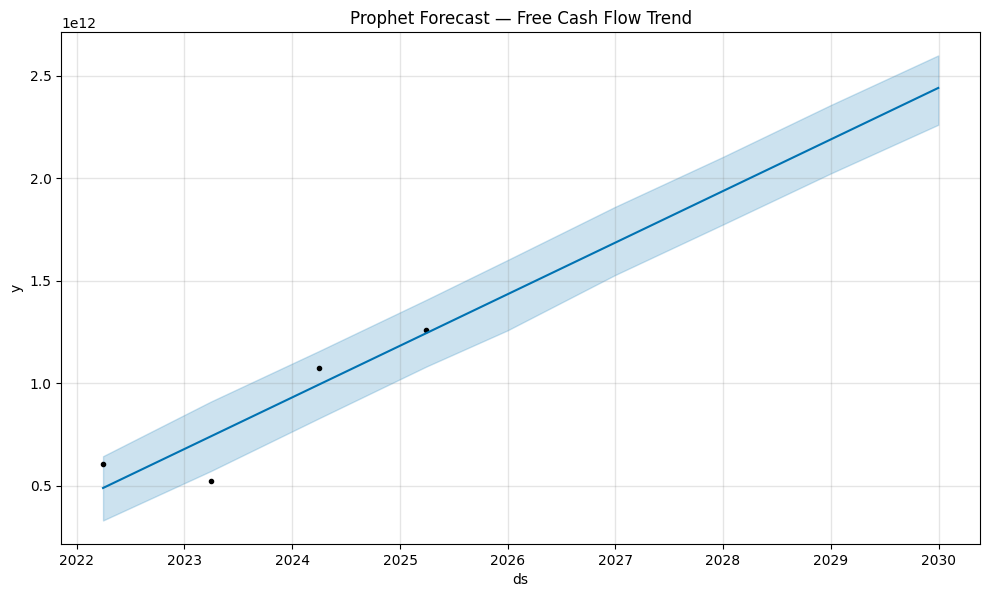

In [28]:
prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast — Free Cash Flow Trend")
plt.show()


Extract Prophet future FCF values:

In [29]:
prophet_future_fcf = prophet_forecast.tail(5)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
prophet_future_fcf


,ds,yhat,yhat_lower,yhat_upper
4,2025-12-31,1.433807e+12,1.257566e+12,1.600781e+12
5,2026-12-31,1.685396e+12,1.527764e+12,1.860547e+12
6,2027-12-31,1.936985e+12,1.773751e+12,2.103828e+12
7,2028-12-31,2.189264e+12,2.023214e+12,2.357156e+12
8,2029-12-31,2.440853e+12,2.261086e+12,2.599566e+12


Adding GRU after LSTM and Prophet :


imports:

In [30]:
import torch
import torch.nn as nn


Define GRU model (stable version):

In [31]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out


initialize GRU model:

In [32]:
gru_model = GRUModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.0005)


Train GRU model (NaN-safe)

In [33]:
epochs = 300

for epoch in range(epochs):
    gru_model.train()
    optimizer.zero_grad()

    output = gru_model(X_train_t)
    loss = criterion(output, y_train_t)

    if torch.isnan(loss):
        print("❌ NaN loss detected — stopping")
        break

    loss.backward()
    torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 0.5)
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, GRU Loss: {loss.item():.6f}")


Epoch 0, GRU Loss: 0.424020
Epoch 50, GRU Loss: 0.209938
Epoch 100, GRU Loss: 0.032187
Epoch 150, GRU Loss: 0.000183
Epoch 200, GRU Loss: 0.000000
Epoch 250, GRU Loss: 0.000000


Generate GRU predictions:

In [34]:
gru_model.eval()
with torch.no_grad():
    gru_train_preds = gru_model(X_train_t).numpy()
    gru_test_preds = gru_model(X_test_t).numpy()


Inverse scaling (manual)

In [35]:
gru_train_preds_inv = gru_train_preds * std + mean
gru_test_preds_inv = gru_test_preds * std + mean


Plot GRU vs Actual FCF:

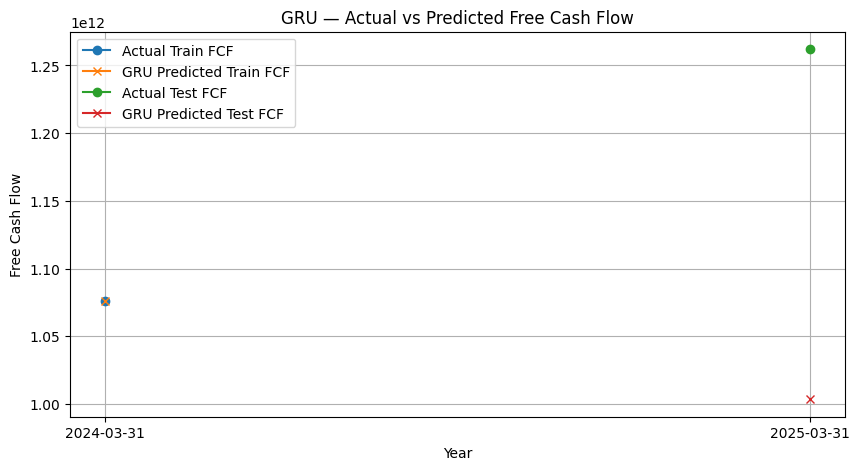

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    fcf.index[LOOK_BACK:LOOK_BACK+len(y_train_inv)],
    y_train_inv,
    label="Actual Train FCF",
    marker="o"
)

plt.plot(
    fcf.index[LOOK_BACK:LOOK_BACK+len(y_train_inv)],
    gru_train_preds_inv,
    label="GRU Predicted Train FCF",
    marker="x"
)

plt.plot(
    fcf.index[LOOK_BACK+len(y_train_inv):],
    y_test_inv,
    label="Actual Test FCF",
    marker="o"
)

plt.plot(
    fcf.index[LOOK_BACK+len(y_train_inv):],
    gru_test_preds_inv,
    label="GRU Predicted Test FCF",
    marker="x"
)

plt.title("GRU — Actual vs Predicted Free Cash Flow")
plt.xlabel("Year")
plt.ylabel("Free Cash Flow")
plt.legend()
plt.grid(True)
plt.show()


GRU Future FCF Forecast (5 years):

In [37]:
future_steps = 5
last_window = fcf_scaled[-LOOK_BACK:]

gru_future_scaled = []

for _ in range(future_steps):
    x = torch.tensor(last_window.reshape(1, LOOK_BACK, 1), dtype=torch.float32)
    with torch.no_grad():
        pred = gru_model(x).numpy()
    gru_future_scaled.append(pred[0,0])
    last_window = np.append(last_window[1:], pred).reshape(LOOK_BACK,1)

gru_future_scaled = np.array(gru_future_scaled).reshape(-1,1)
gru_future_fcf = gru_future_scaled * std + mean

gru_future_fcf


array([[8.97987305e+11],
       [9.27928551e+11],
       [9.73739711e+11],
       [9.62332454e+11],
       [9.57620417e+11]])

Install & import XGBoost:


In [38]:
import xgboost as xgb

Choose base forecast: Prophet seems to be stable and predictable compared to other forecasts.

In [39]:
prophet_hist = prophet_forecast.iloc[:len(fcf)][["yhat"]].values
actual_fcf = fcf["FCF"].values.reshape(-1, 1)


Compute residuals:

In [40]:
residuals = actual_fcf - prophet_hist


Prepare features for XGBoost:

In [41]:
X_res = np.hstack([
    prophet_hist,
    np.arange(len(prophet_hist)).reshape(-1, 1)
])

y_res = residuals


Train XGBoost on residuals:

In [42]:
xgb_model = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_res, y_res)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Residual-corrected FUTURE FCF:

In [43]:
prophet_future_vals = prophet_future_fcf["yhat"].values.reshape(-1,1)

X_future_res = np.hstack([
    prophet_future_vals,
    np.arange(len(prophet_hist), len(prophet_hist)+len(prophet_future_vals)).reshape(-1,1)
])


Predict residual corrections:

In [44]:
future_residuals = xgb_model.predict(X_future_res).reshape(-1,1)


Apply correction:

In [45]:
xgb_corrected_fcf = prophet_future_vals + future_residuals
xgb_corrected_fcf


array([[1.45318870e+12],
       [1.70477793e+12],
       [1.95636716e+12],
       [2.20864568e+12],
       [2.46023491e+12]])

Compare Prophet vs Corrected Forecast:

In [46]:
comparison_df = pd.DataFrame({
    "Year": prophet_future_fcf["ds"].values,
    "Prophet_FCF": prophet_future_vals.flatten(),
    "Corrected_FCF": xgb_corrected_fcf.flatten()
})

comparison_df


,Year,Prophet_FCF,Corrected_FCF
0,2025-12-31,1.433807e+12,1.453189e+12
1,2026-12-31,1.685396e+12,1.704778e+12
2,2027-12-31,1.936985e+12,1.956367e+12
3,2028-12-31,2.189264e+12,2.208646e+12
4,2029-12-31,2.440853e+12,2.460235e+12


Align all future forecasts: LSTM+GRU+Prophet+XGBOOST(Corrected prophet)

In [47]:
ensemble_fcf = np.hstack([
    future_fcf,                          # LSTM
    gru_future_fcf,                      # GRU
    prophet_future_fcf["yhat"].values.reshape(-1,1),  # Prophet
    xgb_corrected_fcf                   # XGB-corrected
])


Compute ensemble mean & uncertainty:

In [48]:
ensemble_mean = np.mean(ensemble_fcf, axis=1).reshape(-1,1)
ensemble_std = np.std(ensemble_fcf, axis=1).reshape(-1,1)


Create final forecast table:

In [49]:
final_forecast_df = pd.DataFrame({
    "Year": prophet_future_fcf["ds"].values,
    "FCF_Mean": ensemble_mean.flatten(),
    "FCF_Upper": (ensemble_mean + ensemble_std).flatten(),
    "FCF_Lower": (ensemble_mean - ensemble_std).flatten()
})

final_forecast_df


,Year,FCF_Mean,FCF_Upper,FCF_Lower
0,2025-12-31,1.183938e+12,1.444258e+12,9.236179e+11
1,2026-12-31,1.321301e+12,1.695406e+12,9.471964e+11
2,2027-12-31,1.464502e+12,1.946763e+12,9.822402e+11
3,2028-12-31,1.586764e+12,2.199054e+12,9.744737e+11
4,2029-12-31,1.710962e+12,2.450640e+12,9.712835e+11


Plot ensemble forecast band:

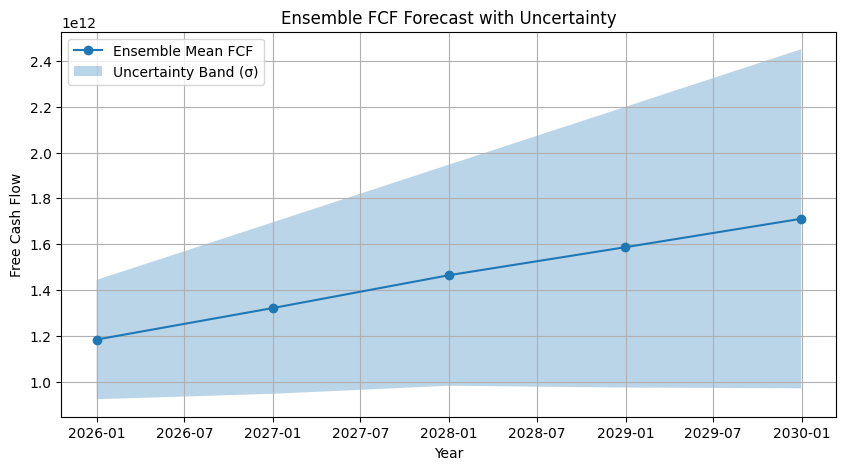

In [50]:
plt.figure(figsize=(10,5))

plt.plot(final_forecast_df["Year"], final_forecast_df["FCF_Mean"],
         label="Ensemble Mean FCF", marker="o")

plt.fill_between(
    final_forecast_df["Year"],
    final_forecast_df["FCF_Lower"],
    final_forecast_df["FCF_Upper"],
    alpha=0.3,
    label="Uncertainty Band (σ)"
)

plt.title("Ensemble FCF Forecast with Uncertainty")
plt.xlabel("Year")
plt.ylabel("Free Cash Flow")
plt.legend()
plt.grid(True)
plt.show()


save final forecast csv:

In [51]:
final_forecast_df.to_csv("../data/final_forecast_fcf.csv", index=False)
